# Lab: Multi-Class Classification

---

## 1. Introduction
In this lab, we'll work with a real-world dataset to predict a person's obesity risk level, which falls into one of several categories. This is a classic multi-class classification problem.

* **Goal:** To preprocess a dataset with mixed data types and train a logictic regression model to predict obesity levels.
* **Data:** The "Obesity Risk Prediction" dataset, which includes demographic data, eating habits, and physical activity information.
* **Strategies:** We will implement and compare the direct multinomial approach with the One-vs-One (OvO) strategy.

---

## 2. Setup and Data Loading

First, let's import the necessary libraries for data processing, modeling, an evaluation.

In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load the data from the URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
data = pd.read_csv(url)

# Display a sample of the data
data.sample(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
1307,Male,22.936098,1.702825,93.638318,yes,yes,2.000000,3.000000,Sometimes,no,1.746197,no,0.455216,0.335158,no,Public_Transportation,Obesity_Type_I
1663,Male,24.079971,1.619810,98.543020,yes,yes,2.958410,2.434347,Sometimes,no,1.000000,no,1.930033,0.754023,no,Public_Transportation,Obesity_Type_II
1501,Male,29.000000,1.641784,89.424947,yes,yes,1.330700,3.000000,Sometimes,no,1.880967,no,0.322013,0.000000,Sometimes,Automobile,Obesity_Type_I
154,Male,22.000000,1.740000,94.000000,yes,yes,2.000000,3.000000,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Obesity_Type_I
861,Female,21.832995,1.580964,65.363941,no,yes,2.021446,3.000000,Sometimes,no,1.077917,no,0.523847,0.808599,Sometimes,Public_Transportation,Overweight_Level_I



---

## 3. Exploratory Data Analysis (EDA)

Let's start by understanding our target variable, `NObeyesdad`. A count plot will show us the distribution of the different obesity levels in the dataset.

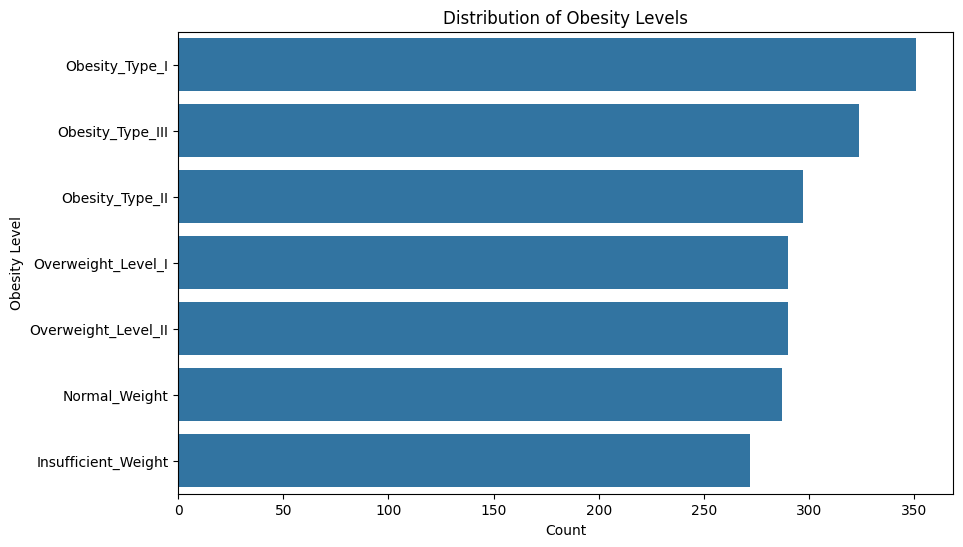

In [4]:
# Visualize the distribution of the target variable
plt.figure(figsize=(10,6))
sns.countplot(data, y='NObeyesdad', order = data['NObeyesdad'].value_counts().index)
plt.title("Distribution of Obesity Levels")
plt.xlabel("Count")
plt.ylabel("Obesity Level")
plt.show()

> 🔍 **Observation:**  
> The classes are reasonably balanced, which is good. We don't have a situation where one class overwhelmingly dominates the others, so accuracy can be a meaningful metric.  

---

## 4. Data Preprocessing

This dataset contains a mix of numerical and categorical features. We need to prepare them properly before feeding them into our model. 

### 4.1. Identify Feature Types
First, we'll separate our columns into numerical and categorical types.

In [10]:
# Identify numerical and categorical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Remove the target variable from the `categorical_cols`
target_col = 'NObeyesdad'
categorical_cols.remove(target_col)

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")

Numerical features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


### 4.2. Separate Features (X) and Target (y)

Let's define our feature matrix `X` and target vector `y`.

In [11]:
X = data.drop(target_col, axis=1)
y = data[target_col]

### 4.3. Split Data into Training and Testing Sets
This is the **most important first step** in preprocessing. We split the data *before* applying any scaling or encoding to prevent data leakage from the test set into our training process. We use `stratify=y` to ensure the class distribution is the same in both the train and test sets.

In [12]:
# Split data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 4.4. Create a Preprocessing Pipeline
We will use `ColumnTransformer` to apply different transformations to different columns:
* `StandardScaler` will be applied to the numerical columns.
* `OneHotEncoder` will be applied to the categorical columns.

We will `fit` this transformer **only on the training data**.

In [13]:
# Create a preprocessor object using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any)
)

# Fit the preprocessor on the training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Use the same fitted preprocessor to transform the test data
X_test_processed = preprocessor.transform(X_test)


---

## 5. Model 1: Logictic Regression with a Multinomial Approach

In the lecture, we learned about the **One-vs-All** strategy where you train one binary classifier for each class. While there's a great concept to understand, `scikit-learn`'s `LogisticRegression` offers a more direct and often better-performing method for multi-class problems.

This is the **"multinomial"** approach. Instead of training multiple separate binary models, it trains a single model that can handle all classes at once. This is generally more efficient and is now the recommended best practice.

By default, `scikit-learn` will automatically use this superior multinomial approach when it detects a multi-class problem.

In [23]:
# Train a logistic regression model using the multinomial strategy
# We use the default parameters, so scikit-learn automatically selects the 'multinomial' approach.
model_multinomial = LogisticRegression(max_iter=1000)
model_multinomial.fit(X_train_processed, y_train)

# Make predictions on the processed test data
y_pred_multinomial = model_multinomial.predict(X_test_processed)

# Evaluate the model
print("======= Classification Report: Multinomial Strategy ========\n")
print(classification_report(y_test, y_pred_multinomial))
print("="*60)

======= Classification Report: Multinomial Strategy ========

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        54
      Normal_Weight       0.81      0.74      0.77        58
     Obesity_Type_I       0.88      0.91      0.90        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.74      0.74      0.74        58
Overweight_Level_II       0.81      0.76      0.79        58

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423

